# Orbital Data Center: Levelized Cost of Compute (LCOC) Model

**Project:** Class analysis of whether passive radiative cooling can offset embodied launch energy and radiator mass costs for an orbital data center (ODC).

**Method:** First-principles sizing of PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1.

**Model structure (revised):**
- **One** baseline ODC scenario (locked physical parameters and 2026 cost inputs).
- **One** terrestrial DC scenario for comparison.
- **Uncertainty** comes from three **learning rate** scenarios (Optimistic / Nominal / Pessimistic) — i.e., how fast each cost component declines over time. This creates a *shaded band* on time-series plots.

**Notebook outline:**
1. Constants and locked assumptions
2. Baseline ODC scenario (parameter table + justification)
3. Learning rate scenarios (parameter table + justification)
4. Physical sizing (PV, radiator, mass)
5. LCOC calculation at year 0
6. Terrestrial DC baseline
7. Time projection 2026–2045 with learning rates
8. Visualizations
   - 8a. LCOC vs time (shaded uncertainty band)
   - 8b. Tornado sensitivity chart
   - 8c. LCOC vs launch cost sweep
9. Summary

## 1. Constants and locked assumptions

**Locked architecture:**
- 100 MW compute payload, training workload, LF = 1
- MEO at 15,000 km altitude (no eclipse, high radiation environment)
- 100% power conditioning efficiency
- 15-year spacecraft lifetime, 5-year IT refresh
- PV and radiator are one-time launches at year 0
- Two angled radiator arms at 45° from vertical, two-sided emission
- Triple-junction GaAs PV cells
- **OPEX = 0, no structural mass overhead**

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import dataclass, replace
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# Physical constants
SIGMA        = 5.67e-8            # Stefan-Boltzmann [W/m^2/K^4]
I_SUN        = 1367               # Solar constant [W/m^2]
T_EARTH_EFF  = 255                # Earth effective radiating temp [K] (-18 C)
EARTH_ALBEDO = 0.30

# Architecture constants
Q_COMPUTE          = 100e6                       # 100 MW
LIFETIME_YR        = 15
REFRESH_INTERVAL   = 5
HOURS_PER_YEAR     = 8765.8
SECONDS_PER_YEAR   = HOURS_PER_YEAR * 3600

## 2. Baseline ODC scenario

Rather than running multiple ODC configurations, we lock the physical hardware to a single defensible 2026 baseline. All future-state uncertainty enters through learning rates (Section 3).

### Baseline parameter table

| Category | Variable | Value | Units | Justification / Source |
|---|---|---|---|---|
| Compute    | Compute Efficiency γ | **6.0** | PFLOPS/kW | NVIDIA B200 / next-gen FP8 |
| Compute    | IT Mass Density      | 25,000 | kg/MW | DGX-class with full chassis |
| Compute    | IT Cost Density      | 10 | M\$/MW | Current H100/B200 deployed pricing |
| Launch     | Launch Cost          | **1,500** | \$/kg | Falcon Heavy to LEO, mid-range for MEO |
| PV         | PV BOL Efficiency    | 0.32 | – | Current SOA space triple-junction (Azur 3G30) |
| PV         | PV Derating          | 0.85 | – | Standard 15-yr MEO degradation |
| PV         | PV Areal Density     | 3 | kg/m² | Standard rigid panels with structure |
| PV         | PV Areal Cost        | 2,500 | \$/m² | Current space-grade pricing |
| PV         | PV View Factor       | 0.15 | – | Modest boom, body-mounted |
| PV         | PV Temperature       | 80 | °C | Typical without active cooling |
| Radiator   | Radiator Areal Density | 5 | kg/m² | Conventional deployable radiator |
| Radiator   | Radiator Areal Cost   | 10,000 | \$/m² | Mid-range aerospace component |
| Radiator   | Radiator Solar Absorptance α_solar | 0.05 | – | Standard space coating (Fan et al. Table 2) |
| Radiator   | Radiator IR Emissivity ε_IR | 0.90 | – | Standard space coating |
| Earth IR   | Earth View Factor    | 0.10 | – | Geometric, 15,000 km altitude |
| Financial  | Discount Rate        | 0.10 | – | Mid-range commercial WACC |
| Data       | Data Drop Cost (fixed) | 1.0 | M\$/drop | Per descent vehicle / recovery |

### Fixed parameters (assumed constant across all scenarios)

| Variable | Value | Units | Note |
|---|---|---|---|
| Radiator Temperature      | 80   | °C    | T_chip = 85 °C, 5 °C drop |
| Radiator Arm Angle        | 45   | °     | From vertical |
| PV IR Emissivity (back)   | 0.85 | –     | – |
| Data Drop Mass            | 1,000 | kg/drop | – |
| Data Drop Rate            | 2    | drops/yr | – |
| ODC Lifespan              | 15   | yrs   | – |
| IT Compute Refresh        | 5    | yrs   | Refreshes at yr 5, 10 |
| ODC Compute Rating        | 100  | MW    | – |
| Solar Constant            | 1,367 | W/m²  | – |
| Orbital Altitude          | 15,000 | km   | MEO |
| Earth Albedo              | 0.30 | –     | – |
| Earth Effective Rad Temp  | −18  | °C    | 255 K |

### Other locked assumptions
- No OPEX
- No structural mass overhead
- No eclipse in MEO
- 100% power conditioning efficiency
- Double-sided radiator emission
- Triple junction GaAs PV cells
- No PV and radiator refresh needed (one-time launches at year 0)
- Chip Temperature of 85 °C, 5 °C chip-to-radiator drop
- One side of radiator arm always sees sun at 45°
- Cooling only compute module (PV thermally isolated)
- 100% utilization, no downtime
- Single TDC scenario (no optimistic/pessimistic TDC variants)
- No radiator coating degradation
- No disposal/decommissioning costs
- No temperature gradients across radiator (single T_rad everywhere)

In [38]:
@dataclass
class Scenario:
    name: str
    gamma_PFLOPS_per_kW: float
    # Radiator
    eps_IR: float; alpha_solar_rad: float
    F_earth: float; F_PV: float
    T_rad_C: float; T_chip_C: float; arm_angle_deg: float
    rad_areal_mass: float; rad_areal_cost: float
    # PV
    pv_eff_BOL: float; pv_derating: float
    T_PV_C: float; eps_PV_back: float
    pv_areal_mass: float; pv_areal_cost: float
    # Compute payload
    it_mass_density: float; it_cost_per_MW: float
    # Launch & data
    launch_cost_per_kg: float
    data_mass_per_drop: float; data_drops_per_year: float; data_fixed_cost: float
    # Financial
    discount_rate: float


BASELINE = Scenario(
    name='Baseline',
    gamma_PFLOPS_per_kW = 2.0,
    eps_IR              = 0.90,
    alpha_solar_rad     = 0.05,
    F_earth             = 0.10,
    F_PV                = 0.15,
    T_rad_C             = 80.0,
    T_chip_C            = 85.0,
    arm_angle_deg       = 45.0,
    rad_areal_mass      = 5.0,
    rad_areal_cost      = 10_000.0,
    pv_eff_BOL          = 0.32,
    pv_derating         = 0.85,
    T_PV_C              = 80.0,
    eps_PV_back         = 0.85,
    pv_areal_mass       = 3.0,
    pv_areal_cost       = 2_500.0,
    it_mass_density     = 25_000.0,
    it_cost_per_MW      = 10e6,
    launch_cost_per_kg  = 1_500.0,
    data_mass_per_drop  = 1_000.0,
    data_drops_per_year = 2.0,
    data_fixed_cost     = 1_000_000.0,
    discount_rate       = 0.10,
)

## 3. Learning rate scenarios

All future-state uncertainty enters through annual % change rates applied to costs and efficiencies. These are time-based (not Wright's-Law cumulative-production-based), which is a simplification but transparent and defensible for a class project.

We define three learning rate scenarios — **Optimistic**, **Nominal**, **Pessimistic**. The shaded band on plots spans the LR-pessimistic ↔ LR-optimistic trajectories; the central line uses LR-nominal.

### Learning rate table

| Parameter | Optimistic | **Nominal** | Pessimistic | Justification |
|---|---|---|---|---|
| Launch cost (\$/kg)         | **−20%/yr** | **−12%/yr** | **−4%/yr** | SpaceX historical trajectory ~15%/yr; bracket optimism on Starship reuse |
| PV areal cost (\$/m²)       | −10%/yr | −6%/yr | −2%/yr | Solar PV historical ~10%/yr; space-grade is slower |
| Radiator areal cost (\$/m²) | −6%/yr  | −3%/yr | −1%/yr | Mature aerospace tech, slow gains |
| IT cost (\$/MW)             | −14%/yr | −8%/yr | −3%/yr | Cost-per-FLOP improvement, slower than performance |
| Compute efficiency γ        | **+22%/yr** | **+15%/yr** | **+7%/yr** | Historical AI hardware ~25%/yr but slowing |
| PV efficiency               | +0.5 pp/yr abs | +0.3 pp/yr abs | +0.1 pp/yr abs | Capped at 40% |
| Terrestrial DC CAPEX (\$/kW) | −4%/yr | −2%/yr | −0.5%/yr | Mature tech, slow gains |
| Electricity price (\$/MWh)  | 0% real | 0% real | 0% real | Flat in real terms |

**Key insight:** γ improvement applies to both ODC and TDC (same chips, same efficiency curve), so γ shifts both curves down in parallel. The **gap** between ODC and TDC is primarily driven by launch cost decline (helps ODC) vs. terrestrial CAPEX decline (helps TDC).

In [39]:
@dataclass
class LearningRates:
    name: str
    launch:       float   # annual decline
    pv_cost:      float
    rad_cost:     float
    it_cost:      float
    gamma_growth: float   # annual growth
    pv_eff_pp:    float   # additive percentage points / yr
    terr_capex:   float
    elec_price:   float = 0.0


LR_OPTIMISTIC = LearningRates(
    name='Optimistic',
    launch=0.20, pv_cost=0.10, rad_cost=0.06, it_cost=0.14,
    gamma_growth=0.22, pv_eff_pp=0.005, terr_capex=0.04,
)
LR_NOMINAL = LearningRates(
    name='Nominal',
    launch=0.12, pv_cost=0.06, rad_cost=0.03, it_cost=0.08,
    gamma_growth=0.15, pv_eff_pp=0.003, terr_capex=0.02,
)
LR_PESSIMISTIC = LearningRates(
    name='Pessimistic',
    launch=0.04, pv_cost=0.02, rad_cost=0.01, it_cost=0.03,
    gamma_growth=0.07, pv_eff_pp=0.001, terr_capex=0.005,
)
LR_SCENARIOS = [LR_OPTIMISTIC, LR_NOMINAL, LR_PESSIMISTIC]

## 4. Physical sizing

PV area sized to deliver `Q_COMPUTE` after BOL efficiency and derating losses. Radiator area sized to reject `Q_COMPUTE` after subtracting solar, albedo, Earth IR, and PV IR heat loads via the standard radiative balance.

$$A_{\mathrm{rad}} = \frac{Q_{\mathrm{compute}}}{2 \varepsilon_{\mathrm{IR}} \sigma T_{\mathrm{rad}}^4 - \alpha_{\mathrm{solar}} I_\odot \cos\theta - \alpha_{\mathrm{solar}} \alpha_{\oplus} I_\odot F_{\oplus} - \varepsilon_{\mathrm{IR}} \sigma T_{\oplus}^4 F_{\oplus} - \varepsilon_{\mathrm{IR}} \varepsilon_{\mathrm{PV,back}} \sigma T_{\mathrm{PV}}^4 F_{\mathrm{PV}}}$$

In [40]:
def size_pv_array(s: Scenario) -> float:
    return Q_COMPUTE / (s.pv_eff_BOL * s.pv_derating * I_SUN)

def size_radiator(s: Scenario, verbose: bool = False) -> float:
    T_rad = s.T_rad_C + 273.15
    T_PV  = s.T_PV_C  + 273.15
    theta = np.radians(s.arm_angle_deg)
    P_emit     = 2 * s.eps_IR * SIGMA * T_rad**4
    P_solar    = s.alpha_solar_rad * I_SUN * np.cos(theta)
    P_albedo   = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
    P_earth_IR = s.eps_IR * SIGMA * T_EARTH_EFF**4 * s.F_earth
    P_PV       = s.eps_IR * s.eps_PV_back * SIGMA * T_PV**4 * s.F_PV
    P_net = P_emit - P_solar - P_albedo - P_earth_IR - P_PV
    if P_net <= 0:
        raise ValueError(f'Net cooling non-positive ({P_net:.1f} W/m^2)')
    if verbose:
        print(f'  Emit:+{P_emit:.0f}  Solar:-{P_solar:.1f}  Albedo:-{P_albedo:.1f}'
              f'  EarthIR:-{P_earth_IR:.1f}  PV-IR:-{P_PV:.1f}  Net:+{P_net:.0f} W/m^2')
    return Q_COMPUTE / P_net

def mass_budget(s: Scenario) -> Dict[str, float]:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    return {
        'PV':       A_PV  * s.pv_areal_mass,
        'Radiator': A_rad * s.rad_areal_mass,
        'IT':       (Q_COMPUTE / 1e6) * s.it_mass_density,
        'Total':    A_PV*s.pv_areal_mass + A_rad*s.rad_areal_mass + (Q_COMPUTE/1e6)*s.it_mass_density,
        'A_PV':     A_PV,
        'A_rad':    A_rad,
    }

print('Physical sizing (baseline scenario):')
A_PV  = size_pv_array(BASELINE)
print(f'  PV array:  {A_PV:>9,.0f} m^2 ({A_PV/10000:.2f} ha)')
A_rad = size_radiator(BASELINE, verbose=True)
print(f'  Radiator:  {A_rad:>9,.0f} m^2 ({A_rad/10000:.2f} ha)')

mb = mass_budget(BASELINE)
print('\nMass budget [tonnes]:')
for k in ['PV', 'Radiator', 'IT', 'Total']:
    print(f'  {k:10s}: {mb[k]/1000:>8,.1f} t')

Physical sizing (baseline scenario):
  PV array:    268,944 m^2 (26.89 ha)
  Emit:+1587  Solar:-48.3  Albedo:-2.1  EarthIR:-21.6  PV-IR:-101.2  Net:+1414 W/m^2
  Radiator:     70,708 m^2 (7.07 ha)

Mass budget [tonnes]:
  PV        :    806.8 t
  Radiator  :    353.5 t
  IT        :  2,500.0 t
  Total     :  3,660.4 t


## 5. LCOC calculation

Following Nøland et al. (2024) Eq. 1. With $\alpha p k t = 0$ (no electricity cost on-orbit) and $dc = 0$ (no OPEX):

$$ \text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma k t / (1+r)^i} $$

Cost streams:
- **Hardware**: PV + radiator + IT at year 0; IT refreshes at years 5 and 10.
- **Launch**: full system mass at year 0; IT-only mass at refresh years.
- **Data**: per-drop fixed cost + return-mass launch cost, each year.

In [41]:
def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year]."""
    return (Q_COMPUTE / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load

def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    mb = mass_budget(s)
    cost_PV  = mb['A_PV']  * s.pv_areal_cost
    cost_rad = mb['A_rad'] * s.rad_areal_cost
    cost_IT  = (Q_COMPUTE / 1e6) * s.it_cost_per_MW
    launch_year0   = mb['Total'] * s.launch_cost_per_kg
    launch_refresh = mb['IT']    * s.launch_cost_per_kg
    hardware = np.zeros(LIFETIME_YR)
    launch   = np.zeros(LIFETIME_YR)
    data     = np.zeros(LIFETIME_YR)
    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0]   = launch_year0
    for ry in [5, 10]:
        hardware[ry] += cost_IT
        launch[ry]   += launch_refresh
    cost_per_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg
    data[:] = cost_per_drop * s.data_drops_per_year
    return {'hardware': hardware, 'launch': launch, 'data': data,
            'total': hardware + launch + data}

def calculate_lcoc(s: Scenario) -> Dict[str, float]:
    cf = build_cash_flows(s)
    years = np.arange(LIFETIME_YR)
    annual_compute = np.full(LIFETIME_YR, annual_eflop(s))
    discount = 1.0 / (1 + s.discount_rate)**years
    npv_cost    = (cf['total']     * discount).sum()
    npv_compute = (annual_compute * discount).sum()
    lcoc = npv_cost / npv_compute
    breakdown = {
        'Hardware': (cf['hardware'] * discount).sum() / npv_compute,
        'Launch':   (cf['launch']   * discount).sum() / npv_compute,
        'Data':     (cf['data']     * discount).sum() / npv_compute,
    }
    return {'lcoc': lcoc, 'breakdown': breakdown, 'npv_cost': npv_cost}

baseline_result = calculate_lcoc(BASELINE)
print(f'Baseline LCOC (2026): ${baseline_result["lcoc"]:.4f}/EFLOP')
print(f'  NPV total cost:     ${baseline_result["npv_cost"]/1e9:.2f}B')
print('  Cost breakdown:')
for k, v in baseline_result['breakdown'].items():
    print(f'    {k:10s} ${v:.4f}/EFLOP  ({v/baseline_result["lcoc"]*100:.1f}%)')

Baseline LCOC (2026): $0.2404/EFLOP
  NPV total cost:     $12.69B
  Cost breakdown:
    Hardware   $0.0641/EFLOP  (26.7%)
    Launch     $0.1755/EFLOP  (73.0%)
    Data       $0.0008/EFLOP  (0.3%)


## 6. Terrestrial DC baseline (Nøland et al. methodology)

Using their Table 5 baseline parameters: $c = \$10{,}000$/kW, $d = 10\%$ (annual OPEX as fraction of CAPEX), $\alpha = 1.12$ (PUE), $p = \$150$/MWh, $r = 10\%$, $n = 15$ years, $k = 1$.

Computed at the **same γ as the ODC baseline** for apples-to-apples comparison.

In [42]:
def terrestrial_lcoc(gamma_PFLOPS_per_kW: float,
                     c_per_kW: float = 10_000,
                     d_frac: float   = 0.10,
                     alpha_PUE: float = 1.12,
                     p_per_MWh: float = 150,
                     r_wacc: float    = 0.10,
                     n_years: int     = 15,
                     k_load: float    = 1.0) -> float:
    """Noland et al. 2024 Eq. 1 - terrestrial LCOC in $/EFLOP."""
    annual_elec    = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex    = d_frac * c_per_kW
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df = np.array([1/(1+r_wacc)**i for i in range(n_years)])
    npv_costs    = c_per_kW + ((annual_elec + annual_opex) * df).sum()
    npv_compute  = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000  # $/PFLOP -> $/EFLOP

# Sanity check vs. paper-reported value at gamma=0.1
verify = terrestrial_lcoc(0.1)
print(f'Verification @ gamma=0.1: ${verify:.3f}/EFLOP (Noland paper says $1.16)')

tdc_baseline = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW)
print(f'\nTDC @ gamma={BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW: ${tdc_baseline:.4f}/EFLOP')
print(f'ODC / TDC ratio: {baseline_result["lcoc"]/tdc_baseline:.2f}x')

Verification @ gamma=0.1: $1.162/EFLOP (Noland paper says $1.16)

TDC @ gamma=2.0 PFLOPS/kW: $0.0581/EFLOP
ODC / TDC ratio: 4.14x


## 7. Time projection 2026–2045

Apply each learning rate scenario to the baseline year over year. Generates three trajectories (Optimistic / Nominal / Pessimistic LRs) for both ODC and TDC.

In [43]:
def evolve_scenario(s_base: Scenario, year_offset: int, lr: LearningRates) -> Scenario:
    """Return s_base evolved year_offset years into the future under learning rates lr."""
    return replace(s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr.gamma_growth)**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr.launch)**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr.pv_cost)**year_offset,
        rad_areal_cost      = s_base.rad_areal_cost      * (1 - lr.rad_cost)**year_offset,
        it_cost_per_MW      = s_base.it_cost_per_MW      * (1 - lr.it_cost)**year_offset,
        pv_eff_BOL          = min(0.40, s_base.pv_eff_BOL + lr.pv_eff_pp * year_offset),
    )

def terrestrial_evolved(gamma_baseline: float, year_offset: int, lr: LearningRates) -> float:
    gamma_t = gamma_baseline * (1 + lr.gamma_growth)**year_offset
    capex_t = 10_000 * (1 - lr.terr_capex)**year_offset
    return terrestrial_lcoc(gamma_t, c_per_kW=capex_t)

# Project each LR scenario forward
START_YEAR, END_YEAR = 2026, 2045
years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets   = years_calendar - START_YEAR

odc_by_lr: Dict[str, np.ndarray] = {}
tdc_by_lr: Dict[str, np.ndarray] = {}

for lr in LR_SCENARIOS:
    odc_vals, tdc_vals = [], []
    for yo in year_offsets:
        ev = evolve_scenario(BASELINE, yo, lr)
        odc_vals.append(calculate_lcoc(ev)['lcoc'])
        tdc_vals.append(terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, lr))
    odc_by_lr[lr.name] = np.array(odc_vals)
    tdc_by_lr[lr.name] = np.array(tdc_vals)

# Convenience aliases
odc_nom = odc_by_lr['Nominal']
odc_hi  = odc_by_lr['Optimistic']   # lower LCOC = cheaper
odc_lo  = odc_by_lr['Pessimistic']  # higher LCOC
tdc_nom = tdc_by_lr['Nominal']
tdc_hi  = tdc_by_lr['Optimistic']
tdc_lo  = tdc_by_lr['Pessimistic']

print(f'{"Year":>6s}  {"ODC Nom":>10s}  {"ODC Opt":>10s}  {"ODC Pes":>10s}  '
      f'{"TDC Nom":>10s}  {"ODC/TDC":>8s}')
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    print(f'{label:>6s}  ${odc_nom[idx]:>9.4f}  ${odc_hi[idx]:>9.4f}  '
          f'${odc_lo[idx]:>9.4f}  ${tdc_nom[idx]:>9.4f}  '
          f'{odc_nom[idx]/tdc_nom[idx]:>7.2f}x')

  Year     ODC Nom     ODC Opt     ODC Pes     TDC Nom   ODC/TDC
  2026  $   0.2404  $   0.2404  $   0.2404  $   0.0581     4.14x
  2030  $   0.0880  $   0.0501  $   0.1584  $   0.0317     2.78x
  2035  $   0.0257  $   0.0076  $   0.0942  $   0.0149     1.73x
  2040  $   0.0077  $   0.0013  $   0.0561  $   0.0070     1.10x
  2045  $   0.0024  $   0.0002  $   0.0335  $   0.0033     0.73x


## 8. Visualizations

All three plots share a unified dark-space aesthetic for the project presentation:
- Pure-black background
- Vivid green for ODC, vivid blue for TDC (swap to white by setting `TDC_COLOR = '#ffffff'`)
- All-white labels and tick marks for high readability
- Poppins font throughout

In [59]:
# Shared styling constants
BG        = '#08090d'
ODC_COLOR = "#b8f73e" #'#3ef576'   # vivid spring green
TDC_COLOR = "#F7F8F8"#'#4d9fff'   # bright sky blue   (alternative: '#ffffff' for white)
ACCENT_R  = '#ff5566'   # red accent for tornado / 'bad' direction
GRID      = '#2a2f40'
WHITE     = '#ffffff'
FONT      = 'Poppins'

# Tick formatters (apply AFTER set_yscale, since log scale resets formatters)
def _fmt_dollar(x, _):
    if x >= 1:    return f'${x:,.0f}'
    if x >= 0.01: return f'${x:.2f}'
    return f'${x:.4f}'

# Helper to apply consistent dark styling to any axes
def style_axes(ax, fig, title, subtitle=None, xlabel=None, ylabel=None,
               y_log=True, x_log=False, ylim=None, xlim=None,
               y_dollar=True, x_dollar=False):
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    if y_log: ax.set_yscale('log')
    if x_log: ax.set_xscale('log')
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)

    ax.grid(True, which='major', color=GRID, alpha=0.5, linewidth=0.6)
    ax.grid(True, which='minor', color=GRID, alpha=0.20, linewidth=0.35)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_color(GRID); sp.set_linewidth(1.0)

    # Apply formatters AFTER scale changes so they aren't reset
    if y_dollar:
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_dollar))
    if x_dollar:
        ax.xaxis.set_major_formatter(FuncFormatter(_fmt_dollar))

    ax.tick_params(colors=WHITE, which='both', labelsize=11)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=WHITE)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=WHITE)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=13, color=WHITE,
                      fontfamily=FONT, labelpad=10, fontweight='medium')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13, color=WHITE,
                      fontfamily=FONT, labelpad=10, fontweight='medium')

    ax.set_title(title, fontsize=17, fontfamily=FONT, color=WHITE,
                 pad=18, loc='left', fontweight='bold')
    if subtitle:
        ax.text(0.0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=10, color=WHITE, fontfamily=FONT, alpha=0.85,
                va='bottom', ha='left')

### 8a. LCOC vs time — projected technology improvement

Both ODC and TDC trajectories shown as shaded bands spanning the pessimistic ↔ optimistic learning rates. Central line = nominal LRs.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

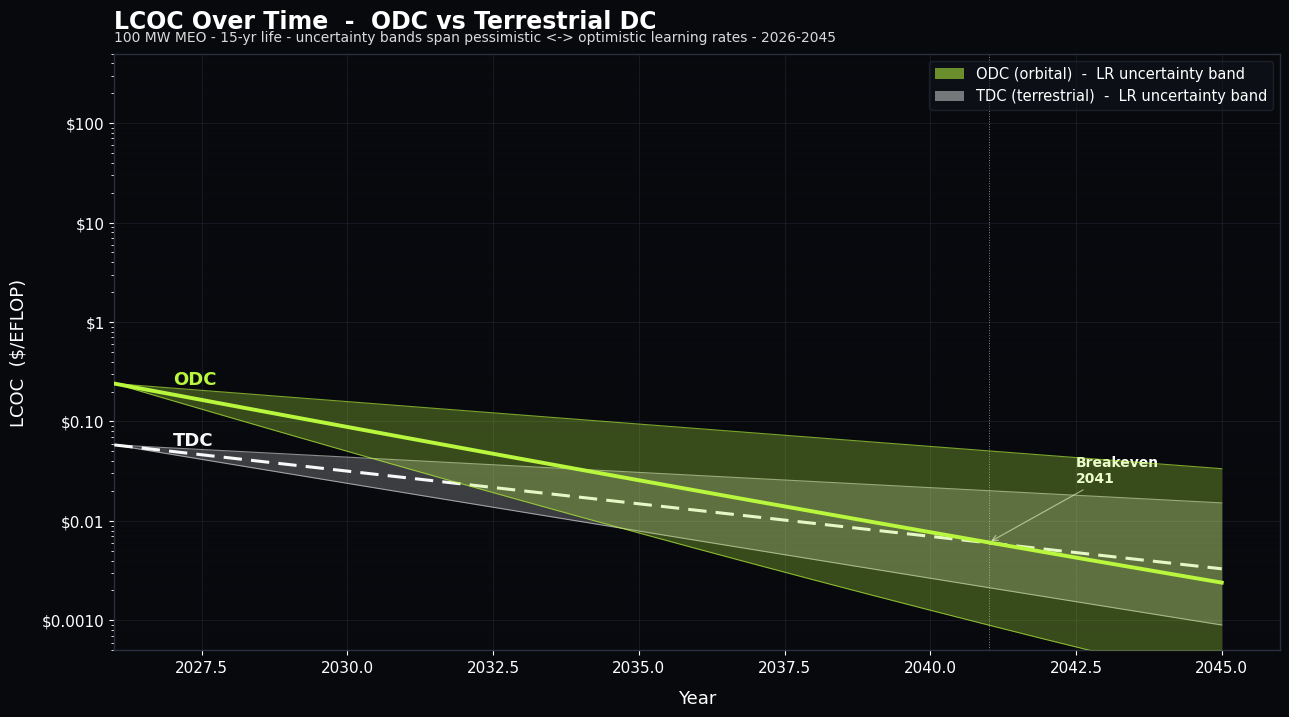

In [60]:
fig, ax = plt.subplots(figsize=(13, 7.5))


# TDC band
ax.fill_between(years_calendar, tdc_lo, tdc_hi, color=TDC_COLOR, alpha=0.22,
                zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_hi, color=TDC_COLOR, linewidth=0.8, alpha=0.55, zorder=3)
ax.plot(years_calendar, tdc_lo, color=TDC_COLOR, linewidth=0.8, alpha=0.55, zorder=3)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=2.2,
        linestyle=(0,(6,3)), zorder=4)

# ODC band
ax.fill_between(years_calendar, odc_lo, odc_hi, color=ODC_COLOR, alpha=0.28,
                zorder=5, linewidth=0)
ax.plot(years_calendar, odc_hi, color=ODC_COLOR, linewidth=0.8, alpha=0.65, zorder=6)
ax.plot(years_calendar, odc_lo, color=ODC_COLOR, linewidth=0.8, alpha=0.65, zorder=6)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=2.8, zorder=7)

# Crossover annotation (where nominal-LR ODC = nominal-LR TDC)
diff = odc_nom - tdc_nom
crosses = np.where(np.diff(np.sign(diff)))[0]
for cx in crosses:
    cy = (odc_nom[cx] + tdc_nom[cx]) / 2
    ax.axvline(years_calendar[cx], color=WHITE, linewidth=0.7,
               linestyle=':', alpha=0.5, zorder=2)
    ax.annotate(f'Breakeven\n{years_calendar[cx]}',
                xy=(years_calendar[cx], cy),
                xytext=(years_calendar[cx]+1.5, cy*4.0),
                fontsize=10, color=WHITE, fontfamily=FONT, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=WHITE, alpha=0.55, lw=0.9))

# End-of-line labels
ax.text(2027, odc_nom[0]*1.1, 'ODC', color=ODC_COLOR, fontfamily=FONT,
        fontsize=13, fontweight='bold', va='center')
ax.text(2027, tdc_nom[0]*1.1, 'TDC', color=TDC_COLOR, fontfamily=FONT,
        fontsize=13, fontweight='bold', va='center')

# Legend
handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.55,
                   label='ODC (orbital)  -  LR uncertainty band'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.45,
                   label='TDC (terrestrial)  -  LR uncertainty band'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True,
                framealpha=0.55, edgecolor=GRID,
                facecolor='#12141e', fontsize=10.5,
                prop={'family': FONT, 'size': 10.5})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='LCOC Over Time  -  ODC vs Terrestrial DC',
    subtitle='100 MW MEO - 15-yr life - uncertainty bands span pessimistic <-> optimistic learning rates - 2026-2045',
    xlabel='Year',
    ylabel='LCOC  ($/EFLOP)',
    xlim=(2026, 2046),
    ylim=(0.0005, 500),
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 8b. Tornado sensitivity chart

Each row swings one variable up and down independently and records the resulting LCOC. Rows are sorted by total swing magnitude — the variables at the top dominate cost uncertainty. Green = cheaper-LCOC direction; red = more-expensive direction.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

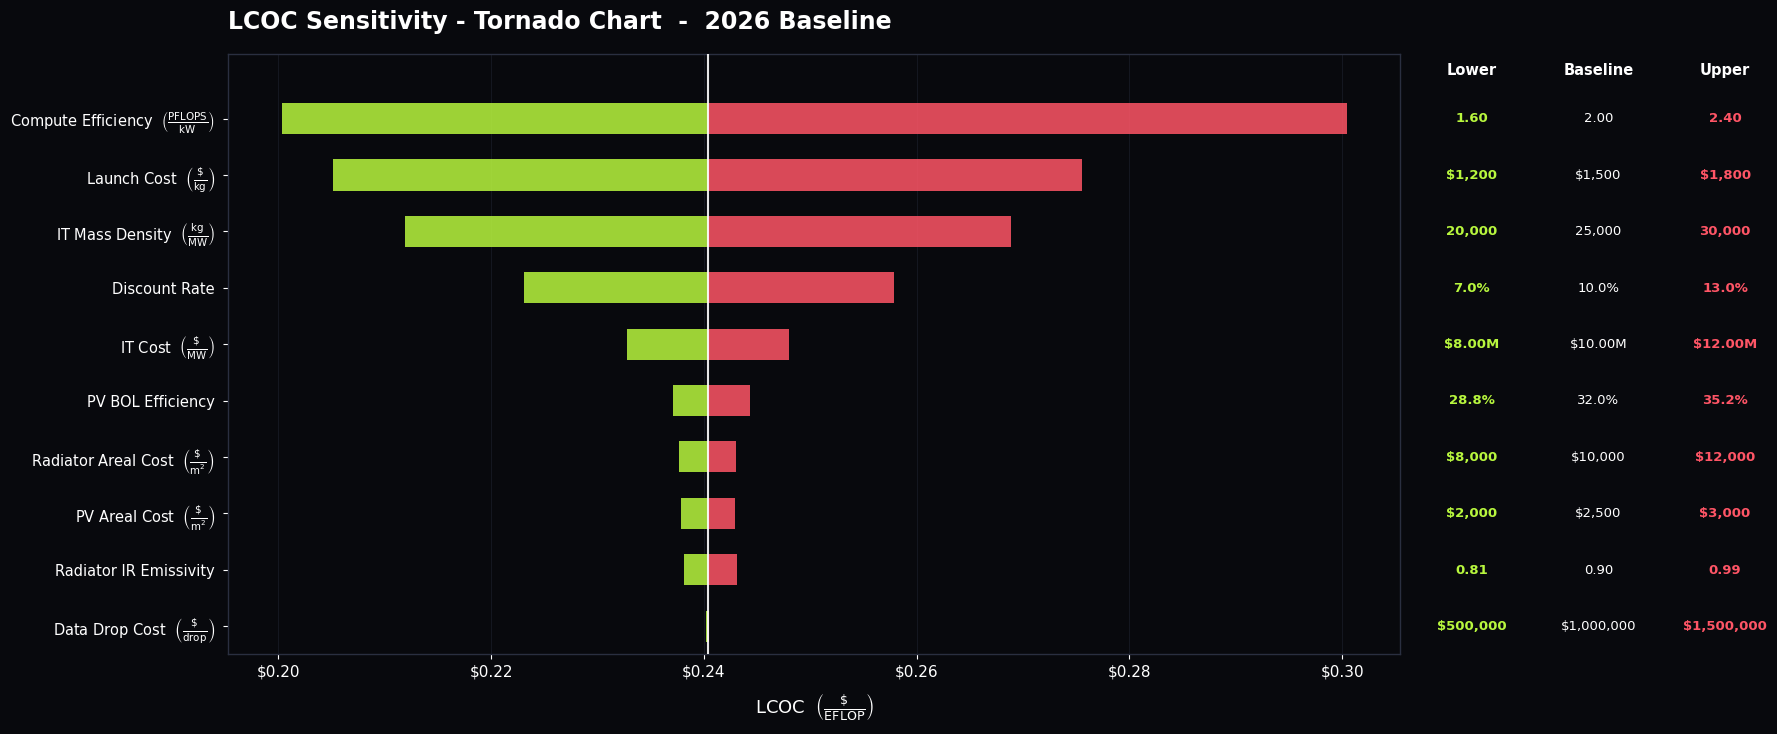

In [66]:
# Parameters to vary, with ±range
PARAMS_TO_VARY = [
    (
        'Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
        'launch_cost_per_kg',
        0.20,
    ),
    (
        'Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
        'gamma_PFLOPS_per_kW',
        0.20,
    ),
    (
        'IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
        'it_cost_per_MW',
        0.20,
    ),
    (
        'Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
        'rad_areal_cost',
        0.20,
    ),
    (
        'Discount Rate',
        'discount_rate',
        0.30,
    ),
    (
        'PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
        'pv_areal_cost',
        0.20,
    ),
    (
        'Radiator IR Emissivity',
        'eps_IR',
        0.10,
    ),
    (
        'PV BOL Efficiency',
        'pv_eff_BOL',
        0.10,
    ),
    (
        'IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
        'it_mass_density',
        0.20,
    ),
    (
        'Data Drop Cost  ' + r'$\left(\frac{\$}{\mathrm{drop}}\right)$',
        'data_fixed_cost',
        0.50,
    ),
]


def format_param_value(attr, value):
    """Pretty formatter for the Lower / Baseline / Upper value table."""
    if attr in ["discount_rate", "pv_eff_BOL"]:
        return f"{100 * value:.1f}%"
    elif attr == "eps_IR":
        return f"{value:.2f}"
    elif attr in ["launch_cost_per_kg", "rad_areal_cost", "pv_areal_cost", "data_fixed_cost"]:
        return f"${value:,.0f}"
    elif attr == "it_cost_per_MW":
        return f"${value / 1e6:.2f}M"
    elif attr == "it_mass_density":
        return f"{value:,.0f}"
    elif attr == "gamma_PFLOPS_per_kW":
        return f"{value:.2f}"
    else:
        return f"{value:,.3g}"


base_lcoc = calculate_lcoc(BASELINE)["lcoc"]

bars = []

for label, attr, delta in PARAMS_TO_VARY:
    base_val = getattr(BASELINE, attr)

    low_param_val = base_val * (1 - delta)
    high_param_val = base_val * (1 + delta)

    lcoc_hi = calculate_lcoc(
        replace(BASELINE, **{attr: high_param_val})
    )["lcoc"]

    lcoc_lo = calculate_lcoc(
        replace(BASELINE, **{attr: low_param_val})
    )["lcoc"]

    left = min(lcoc_lo, lcoc_hi)
    right = max(lcoc_lo, lcoc_hi)
    swing = right - left

    bars.append((
        label,
        attr,
        left,
        right,
        swing,
        low_param_val,
        base_val,
        high_param_val,
    ))

# Sort by LCOC swing magnitude
bars.sort(key=lambda x: x[4], reverse=True)


# ------------------------------------------------------------------
# Figure layout
# Main tornado plot gets most of the width.
# Right-side value table gets its own axis so the chart does not squish.
# ------------------------------------------------------------------

fig = plt.figure(figsize=(19, 7.8))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[7.0, 2.1],
    left=0.17,
    right=0.98,
    top=0.88,
    bottom=0.11,
    wspace=0.02,
)

ax = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])


# ------------------------------------------------------------------
# Tornado bars
# ------------------------------------------------------------------

bar_h = 0.55

for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):

    ax.barh(
        i,
        left_v - base_lcoc,
        left=base_lcoc,
        height=bar_h,
        color=ODC_COLOR,
        alpha=0.85,
        zorder=3,
    )

    ax.barh(
        i,
        right_v - base_lcoc,
        left=base_lcoc,
        height=bar_h,
        color=ACCENT_R,
        alpha=0.85,
        zorder=3,
    )


# Baseline vertical line only
ax.axvline(
    base_lcoc,
    color=WHITE,
    linewidth=1.5,
    alpha=0.9,
    zorder=5,
)


style_axes(
    ax,
    fig,
    title="LCOC Sensitivity - Tornado Chart  -  2026 Baseline",
    xlabel=r"LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$",
    y_log=False,
    y_dollar=False,
    x_dollar=True,
)


# Reapply categorical y-tick labels after style_axes
ax.set_yticks(range(len(bars)))
ax.set_yticklabels(
    [b[0] for b in bars],
    fontfamily=FONT,
    color=WHITE,
    fontsize=10.5,
)

ax.tick_params(axis="y", pad=6)

ax.grid(axis="y", alpha=0)
ax.grid(axis="x", color=GRID, alpha=0.45, linewidth=0.6)

# Largest swing at the top, with extra space for the table header
ax.set_ylim(len(bars) - 0.5, -1.15)


# ------------------------------------------------------------------
# Right-side value table
# ------------------------------------------------------------------

ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis("off")

table_x_low = 0.16
table_x_base = 0.52
table_x_high = 0.88

header_y = -0.85

ax_tbl.text(
    table_x_low,
    header_y,
    "Lower",
    ha="center",
    va="center",
    fontsize=10.5,
    color=WHITE,
    fontfamily=FONT,
    fontweight="bold",
)

ax_tbl.text(
    table_x_base,
    header_y,
    "Baseline",
    ha="center",
    va="center",
    fontsize=10.5,
    color=WHITE,
    fontfamily=FONT,
    fontweight="bold",
)

ax_tbl.text(
    table_x_high,
    header_y,
    "Upper",
    ha="center",
    va="center",
    fontsize=10.5,
    color=WHITE,
    fontfamily=FONT,
    fontweight="bold",
)

for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):

    ax_tbl.text(
        table_x_low,
        i,
        format_param_value(attr, low_val),
        ha="center",
        va="center",
        fontsize=9.5,
        color=ODC_COLOR,
        fontfamily=FONT,
        fontweight="bold",
    )

    ax_tbl.text(
        table_x_base,
        i,
        format_param_value(attr, mid_val),
        ha="center",
        va="center",
        fontsize=9.5,
        color=WHITE,
        fontfamily=FONT,
    )

    ax_tbl.text(
        table_x_high,
        i,
        format_param_value(attr, high_val),
        ha="center",
        va="center",
        fontsize=9.5,
        color=ACCENT_R,
        fontfamily=FONT,
        fontweight="bold",
    )


plt.show()

### 8c. ODC LCOC vs Launch Cost (with time projection)

Sweep launch cost from \$50/kg (Starship-mature) to \$5,000/kg (current commercial average). Three curves: 2026 (current), 2035, and 2045 under nominal learning rates. The 2035/2045 curves shift down both because launch cost itself declines AND because γ improves. Circles mark where the nominal launch cost lands in each year.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

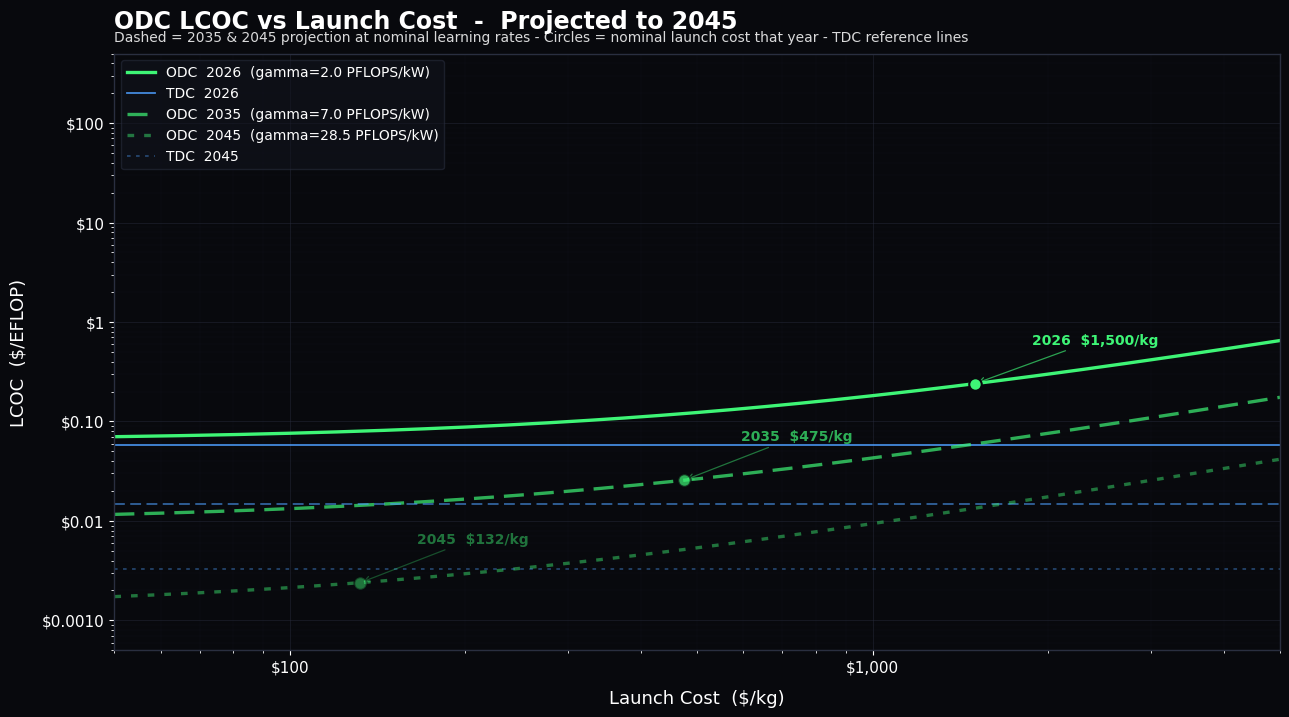

In [47]:
launch_costs  = np.logspace(np.log10(50), np.log10(5000), 200)
years_to_show = {'2026': 0, '2035': 9, '2045': 19}
line_alphas   = {'2026': 1.00, '2035': 0.70, '2045': 0.45}
line_styles   = {'2026': 'solid', '2035': (0,(6,3)), '2045': (0,(2,3))}

fig, ax = plt.subplots(figsize=(13, 7.5))

for yr_label, yo in years_to_show.items():
    ev_base = evolve_scenario(BASELINE, yo, LR_NOMINAL)
    tdc_yr  = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, LR_NOMINAL)
    lcocs = np.array([
        calculate_lcoc(replace(ev_base, launch_cost_per_kg=lc))['lcoc']
        for lc in launch_costs
    ])
    a  = line_alphas[yr_label]
    ls = line_styles[yr_label]

    # ODC curve
    ax.plot(launch_costs, lcocs, color=ODC_COLOR, linewidth=2.4,
            linestyle=ls, alpha=a,
            label=f'ODC  {yr_label}  (gamma={ev_base.gamma_PFLOPS_per_kW:.1f} PFLOPS/kW)')

    # Marker at nominal launch cost evolved to that year
    nom_lc   = BASELINE.launch_cost_per_kg * (1 - LR_NOMINAL.launch)**yo
    nom_lcoc = calculate_lcoc(replace(ev_base, launch_cost_per_kg=nom_lc))['lcoc']
    ax.plot(nom_lc, nom_lcoc, 'o', color=ODC_COLOR, markersize=9,
            alpha=a, zorder=10, markeredgecolor=BG, markeredgewidth=1.5)
    # Label position: offset up and right so it stays inside the plot
    ax.annotate(f'{yr_label}  ${nom_lc:,.0f}/kg',
                xy=(nom_lc, nom_lcoc),
                xytext=(nom_lc * 1.25, nom_lcoc * 2.5),
                fontsize=10, color=ODC_COLOR, fontfamily=FONT,
                alpha=a, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=ODC_COLOR,
                                alpha=a*0.65, lw=0.9))

    # TDC reference for that year
    ax.axhline(tdc_yr, color=TDC_COLOR, linewidth=1.3,
               linestyle=ls, alpha=a*0.85,
               label=f'TDC  {yr_label}' if yr_label in ('2026', '2045') else None)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.55,
                edgecolor=GRID, facecolor='#12141e',
                prop={'family': FONT, 'size': 10})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='ODC LCOC vs Launch Cost  -  Projected to 2045',
    subtitle='Dashed = 2035 & 2045 projection at nominal learning rates - Circles = nominal launch cost that year - TDC reference lines',
    xlabel='Launch Cost  ($/kg)',
    ylabel='LCOC  ($/EFLOP)',
    x_log=True, y_log=True,
    xlim=(50, 5000), ylim=(0.0005, 500),
    x_dollar=True, y_dollar=True,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Summary

In [48]:
print('=' * 78)
print('SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)')
print('=' * 78)
print(f'\nBaseline ODC parameters (locked, 2026):')
print(f'  gamma = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW, Launch = ${BASELINE.launch_cost_per_kg:,.0f}/kg')
print(f'  PV eta_BOL = {BASELINE.pv_eff_BOL}, alpha_solar = {BASELINE.alpha_solar_rad}, eps_IR = {BASELINE.eps_IR}')
print(f'\nLR scenarios drive uncertainty band on plots.')
print()

print(f'{"Year":>6s}  |  {"ODC range":>26s}  {"TDC range":>26s}  | ratio (nom)')
print(f'{"":>6s}  |  {"$/EFLOP (pes/nom/opt)":>26s}  {"$/EFLOP (pes/nom/opt)":>26s}  |')
print('-' * 96)
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    odc_range = f'${odc_lo[idx]:.4f} / ${odc_nom[idx]:.4f} / ${odc_hi[idx]:.4f}'
    tdc_range = f'${tdc_lo[idx]:.4f} / ${tdc_nom[idx]:.4f} / ${tdc_hi[idx]:.4f}'
    print(f'{label:>6s}  |  {odc_range:>26s}  {tdc_range:>26s}  |  {odc_nom[idx]/tdc_nom[idx]:.2f}x')

print()
print('Cost breakdown for 2026 baseline:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP  ({v/baseline_result["lcoc"]*100:.1f}%)')

print()
print('Key takeaways:')
print('  - Launch cost dominates LCOC uncertainty - see tornado chart for confirmation.')
print('  - gamma improvement applies to both ODC and TDC; alone, it does not close the gap.')
print('  - The ODC vs TDC gap is driven by differential learning: launch cost decline (ODC)')
print('    vs. TDC CAPEX decline. Under nominal LRs, ODC trajectory is steeper than TDC.')

SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)

Baseline ODC parameters (locked, 2026):
  gamma = 2.0 PFLOPS/kW, Launch = $1,500/kg
  PV eta_BOL = 0.32, alpha_solar = 0.05, eps_IR = 0.9

LR scenarios drive uncertainty band on plots.

  Year  |                   ODC range                   TDC range  | ratio (nom)
        |       $/EFLOP (pes/nom/opt)       $/EFLOP (pes/nom/opt)  |
------------------------------------------------------------------------------------------------
  2026  |  $0.2404 / $0.2404 / $0.2404  $0.0581 / $0.0581 / $0.0581  |  4.14x
  2030  |  $0.1584 / $0.0880 / $0.0501  $0.0438 / $0.0317 / $0.0239  |  2.78x
  2035  |  $0.0942 / $0.0257 / $0.0076  $0.0308 / $0.0149 / $0.0079  |  1.73x
  2040  |  $0.0561 / $0.0077 / $0.0013  $0.0216 / $0.0070 / $0.0027  |  1.10x
  2045  |  $0.0335 / $0.0024 / $0.0002  $0.0152 / $0.0033 / $0.0009  |  0.73x

Cost breakdown for 2026 baseline:
  Hardware   $0.0641/EFLOP  (26.7%)
  Launch     $0.1755/EFLOP  (73.0%)
  Data       $0.0